In [1]:
!pip install ablang2 peft torch scipy scikit-learn pandas numpy xgboost


In [2]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path
from scipy.stats import spearmanr
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

import ablang2
from peft import LoraConfig, TaskType, get_peft_model


In [3]:
GDPA1_DATA_PATH = "GDPa1_v1.2_20250814.csv"
OUTPUT_DIR  = "results/ablang2_developability"
os.makedirs(OUTPUT_DIR, exist_ok=True)

VH_COL = "vh_protein_sequence"
VL_COL = "vl_protein_sequence"
FOLD_COL = "hierarchical_cluster_IgG_isotype_stratified_fold"
LABEL_COL = "label" # 1 = approved, 0 = not approved

REGRESSION_TARGETS = [
    "HIC", "SMAC", "HAC", "PR_Ova", "PR_CHO",
    "SEC_%Monomer", "AC-SINS_pH6.0", "AC-SINS_pH7.4",
    "Tm1", "Tm2", "Titer",
]

# LoRA hyperparameters
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.1

# Training hyperparameters
EPOCHS = 30
BATCH_SIZE = 8
LR = 1e-4
WEIGHT_DECAY = 1e-2
HEAD_DROPOUT = 0.1

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Using device: {DEVICE}")


Using device: cuda


In [4]:
df = pd.read_csv(GDPA1_DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

approved_mask = df['highest_clinical_trial_asof_feb2025'] == 'Approved'
not_approved_mask = ((df['est_status_asof_feb2025'] == 'Discontinued') & ~approved_mask)

df_model = df[approved_mask | not_approved_mask].copy()
df_model['label'] = approved_mask[approved_mask | not_approved_mask].astype(int)

print(f'Antibodies for modeling: {len(df_model)}')
print(f'Approved: {df_model["label"].sum()}')
print(f'Not-approved: {(df_model["label"] == 0).sum()}')

print(f"Dataset shape (approved, not approved): {df_model.shape}")
df_model.head()

Dataset shape: (246, 30)
Columns: ['antibody_id', 'antibody_name', 'Titer', 'Purity', 'SEC %Monomer', 'SMAC', 'HIC', 'HAC', 'PR_CHO', 'PR_Ova', 'AC-SINS_pH6.0', 'AC-SINS_pH7.4', 'Tonset', 'Tm1', 'Tm2', 'hc_subtype', 'lc_subtype', 'highest_clinical_trial_asof_feb2025', 'est_status_asof_feb2025', 'vh_protein_sequence', 'hc_protein_sequence', 'hc_dna_sequence', 'vl_protein_sequence', 'lc_protein_sequence', 'lc_dna_sequence', 'hierarchical_cluster_fold', 'random_fold', 'hierarchical_cluster_IgG_isotype_stratified_fold', 'light_aligned_aho', 'heavy_aligned_aho']
Antibodies for modeling: 198
Approved: 106
Not-approved: 92
Dataset shape (approved, not approved): (198, 31)


,antibody_id,antibody_name,Titer,Purity,SEC %Monomer,SMAC,HIC,HAC,PR_CHO,PR_Ova,...,hc_dna_sequence,vl_protein_sequence,lc_protein_sequence,lc_dna_sequence,hierarchical_cluster_fold,random_fold,hierarchical_cluster_IgG_isotype_stratified_fold,light_aligned_aho,heavy_aligned_aho,label
0,GDPa1-001,abagovomab,140.25,98.530,97.010,2.730,2.590,NaN,0.337837,0.263108,...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIELTQSPASLSASVGETVTITCQASENIYSYLAWHQQKQGKSPQL...,MRAWIFFLLCLAGRALADIELTQSPASLSASVGETVTITCQASENI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,1,2,2,DIELTQSPASLSASVGETVTITCQAS--ENIY------SYLAWHQQ...,QVKLQES-GAELARPGASVKLSCKASG-YTFTN-----YWMQWVKQ...,0
2,GDPa1-003,abrezekimab,114.75,98.350,89.055,2.740,2.705,NaN,0.138773,0.101180,...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIQMTQSPSSLSASVGDRVTITCLASEDISNYLAWYQQKPGKAPKL...,MRAWIFFLLCLAGRALADIQMTQSPSSLSASVGDRVTITCLASEDI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,2,2,2,DIQMTQSPSSLSASVGDRVTITCLAS--EDIS------NYLAWYQQ...,QVTLKES-GPVLVKPTETLTLTCTVSG-FSLTN-----YHVQWIRQ...,0
3,GDPa1-004,abrilumab,327.32,98.575,98.605,2.715,2.565,1.005,0.000000,0.054971,...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIQMTQSPSSVSASVGDRVTITCRASQGISSWLAWYQQKPGKAPKL...,MRAWIFFLLCLAGRALADIQMTQSPSSVSASVGDRVTITCRASQGI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,1,3,0,DIQMTQSPSSVSASVGDRVTITCRAS--QGIS------SWLAWYQQ...,QVQLVQS-GAEVKKPGASVKVSCKVSG-YTLSD-----LSIHWVRQ...,0
4,GDPa1-005,adalimumab,313.39,99.300,96.120,2.705,2.495,NaN,0.183387,0.085628,...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIQMTQSPSSLSASVGDRVTITCRASQGIRNYLAWYQQKPGKAPKL...,MRAWIFFLLCLAGRALADIQMTQSPSSLSASVGDRVTITCRASQGI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,0,2,0,DIQMTQSPSSLSASVGDRVTITCRAS--QGIR------NYLAWYQQ...,EVQLVES-GGGLVQPGRSLRLSCAASG-FTFDD-----YAMHWVRQ...,1
5,GDPa1-006,aducanumab,367.30,91.565,99.840,2.725,2.460,NaN,0.338749,0.311388,...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIQMTQSPSSLSASVGDRVTITCRASQSISSYLNWYQQKPGKAPKL...,MRAWIFFLLCLAGRALADIQMTQSPSSLSASVGDRVTITCRASQSI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,0,1,0,DIQMTQSPSSLSASVGDRVTITCRAS--QSIS------SYLNWYQQ...,QVQLVES-GGGVVQPGRSLRLSCAASG-FAFSS-----YGMHWVRQ...,1


In [5]:
print(f"Fold distribution:\n{df[FOLD_COL].value_counts().sort_index()}")
if LABEL_COL in df_model.columns:
    print(f"\nApproval labels:\n{df_model[LABEL_COL].value_counts()}")


Fold distribution:
hierarchical_cluster_IgG_isotype_stratified_fold
0    54
1    49
2    48
3    46
4    49
Name: count, dtype: int64

Approval labels:
label
1    106
0     92
Name: count, dtype: int64


In [ ]:
# Wraps the AbLang2 AbRep encoder and injects LoRA adapters into every MultiHeadAttention block (q_proj, k_proj, v_proj, out_proj)
# Returns mean-pooled [B, hidden_size] embeddings ignoring padding tokens

class AbLang2LoRAEncoder(nn.Module):
    LORA_TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "out_proj"]

    def __init__(self, ablang2_model, lora_r: int = LORA_R, lora_alpha: int = LORA_ALPHA, lora_dropout: float = LORA_DROPOUT, freeze_non_lora: bool = True):
        super().__init__()
        self.ablang = ablang2_model
        self.tokenizer = ablang2_model.tokenizer
        self.padding_tkn = ablang2_model.AbLang.AbRep.padding_tkn

        lora_cfg = LoraConfig(
            r = lora_r,
            lora_alpha = lora_alpha,
            lora_dropout = lora_dropout,
            target_modules = self.LORA_TARGET_MODULES,
            bias = "none",
            task_type = TaskType.FEATURE_EXTRACTION,
        )
        self.ablang.AbLang = get_peft_model(self.ablang.AbLang, lora_cfg)

        if freeze_non_lora:
            for name, param in self.ablang.AbLang.named_parameters():
                if "lora_" not in name:
                    param.requires_grad_(False)

        n_trainable = sum(p.numel() for p in self.ablang.AbLang.parameters() if p.requires_grad)
        n_total = sum(p.numel() for p in self.ablang.AbLang.parameters())
        print(f"LoRA injected: {n_trainable:,} trainable / {n_total:,} total "f"({100 * n_trainable / n_total:.2f}%)")

    def tokenize(self, vh_seqs, vl_seqs, device):
        # For 'ablang2-paired', the tokenizer expects a list of (heavy_seq, light_seq) tuples
        # when w_extra_tkns is True (which the error implies it is internally set to).
        paired_sequences = list(zip(vh_seqs, vl_seqs))
        tokens = self.tokenizer(paired_sequences, pad=True, w_extra_tkns=True)
        return tokens.to(device)

    # tokens: LongTensor [B, L] -> mean-pooled [B, H]
    def forward(self, tokens):
        reps = self.ablang.AbLang.AbRep(tokens)
        hidden = reps.last_hidden_states
        pad_mask = tokens.eq(self.padding_tkn).unsqueeze(-1)
        hidden = hidden.masked_fill(pad_mask, 0.0)
        lengths = (~pad_mask).sum(dim = 1).clamp(min = 1).float()
        return hidden.sum(dim=1) / lengths

In [7]:
# Binary classifier on top of pooled AbLang2 embeddings.
class ApprovalHead(nn.Module):
    def __init__(self, hidden_size: int, dropout: float = HEAD_DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, emb):
        return self.net(emb).squeeze(-1)

# Single-target regression head
class RegressionHead(nn.Module):
    def __init__(self, hidden_size: int, dropout: float = HEAD_DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, emb):
        return self.net(emb).squeeze(-1)

In [ ]:
class AntibodyDataset(Dataset):
    def __init__(self, vh_seqs, vl_seqs, labels):
        self.vh = vh_seqs
        self.vl = vl_seqs
        self.labels = labels

    def __len__(self):
        return len(self.vh)

    def __getitem__(self, idx):
        return self.vh[idx], self.vl[idx], self.labels[idx]


# Aggregate all antibodies together
def collate_fn(batch):
    vh, vl, labels = zip(*batch)
    return list(vh), list(vl), torch.tensor(labels, dtype = torch.float32)

# Train AbLang2
def train_epoch(encoder, head, loader, optimizer, loss_fn, device):
    encoder.train()
    head.train()
    total_loss = 0.0

    for vh, vl, labels in loader:
        tokens = encoder.tokenize(vh, vl, device)
        labels = labels.to(device)
        optimizer.zero_grad()
        emb = encoder(tokens)
        preds = head(emb)
        loss = loss_fn(preds, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(
            list(encoder.parameters()) + list(head.parameters()), max_norm=1.0
        )
        optimizer.step()
        total_loss += loss.item() * len(labels)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def predict(encoder, head, loader, device):
    encoder.eval()
    head.eval()
    all_preds, all_labels = [], []

    for vh, vl, labels in loader:
        tokens = encoder.tokenize(vh, vl, device)
        embedding = encoder(tokens)
        preds = head(embedding).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())

    return np.concatenate(all_preds), np.concatenate(all_labels)


def make_loaders(train_df, test_df, y_train, y_test_dummy, vh_col, vl_col):
    train_ds = AntibodyDataset(train_df[vh_col].tolist(), train_df[vl_col].tolist(), y_train)
    test_ds  = AntibodyDataset(test_df[vh_col].tolist(),  test_df[vl_col].tolist(),  y_test_dummy)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
    test_loader = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
    return train_loader, test_loader

In [9]:
# Five fold cross validation

def run_approval_cv(df, device = DEVICE):
    approval_df = df.dropna(subset = [LABEL_COL]).copy()
    print(f"Approval dataset: {len(approval_df)} antibodies | "
          f"{int(approval_df[LABEL_COL].sum())} approved / "
          f"{int((approval_df[LABEL_COL] == 0).sum())} not approved")

    folds = sorted(approval_df[FOLD_COL].unique())
    results = []

    for fold in folds:
        print(f"\n Fold {fold}")
        train_df = approval_df[approval_df[FOLD_COL] != fold].reset_index(drop = True)
        test_df = approval_df[approval_df[FOLD_COL] == fold].reset_index(drop = True)

        y_train = train_df[LABEL_COL].values.astype(np.float32)
        y_test = test_df[LABEL_COL].values.astype(np.float32)

        # For each fold, create a new predictor head
        base = ablang2.pretrained(model_to_use = "ablang2-paired", device = str(device))
        encoder = AbLang2LoRAEncoder(base).to(device)
        hidden_size = base.hparams.hidden_embed_size
        head = ApprovalHead(hidden_size).to(device)

        train_loader, test_loader = make_loaders(train_df, test_df, y_train, np.zeros(len(test_df), dtype = np.float32), VH_COL, VL_COL)

        # Weighted binary cross entropy for class imbalance
        pos_weight = torch.tensor([(y_train == 0).sum() / max((y_train == 1).sum(), 1)], dtype = torch.float32).to(device)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight = pos_weight)

        # Adam optimizer, Cosine Annealing Scheduler
        optimizer = torch.optim.AdamW([p for p in list(encoder.parameters()) + list(head.parameters()) if p.requires_grad], lr = LR, weight_decay = WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = EPOCHS, eta_min = LR * 0.01)

        for epoch in range(EPOCHS):
            loss = train_epoch(encoder, head, train_loader, optimizer, loss_fn, device)
            scheduler.step()

            if (epoch + 1) % 5 == 0:
                preds, _ = predict(encoder, head, test_loader, device)
                probs = torch.sigmoid(torch.tensor(preds)).numpy()
                ap = average_precision_score(y_test, probs)
                print(f"Epoch {epoch+1:3d}/{EPOCHS} | loss={loss:.4f} | AUPRC={ap:.3f}")

        preds, _ = predict(encoder, head, test_loader, device)
        probs = torch.sigmoid(torch.tensor(preds)).numpy()
        auprc = average_precision_score(y_test, probs)
        auroc = roc_auc_score(y_test, probs)
        print(f"Fold {fold} final | AUPRC = {auprc:.3f} | AUROC = {auroc:.3f}")
        results.append({"fold": fold, "AUPRC": auprc, "AUROC": auroc})

    return pd.DataFrame(results)

In [10]:
approval_results = run_approval_cv(df_model, device = DEVICE)

Approval dataset: 198 antibodies | 106 approved / 92 not approved

 Fold 0
LoRA injected: 368,640 trainable / 45,179,690 total (0.82%)
Epoch   5/30 | loss=0.6670 | AUPRC=0.648
Epoch  10/30 | loss=0.6638 | AUPRC=0.636
Epoch  15/30 | loss=0.6616 | AUPRC=0.627
Epoch  20/30 | loss=0.6593 | AUPRC=0.623
Epoch  25/30 | loss=0.6592 | AUPRC=0.625
Epoch  30/30 | loss=0.6583 | AUPRC=0.622
Fold 0 final | AUPRC = 0.622 | AUROC = 0.519

 Fold 1
LoRA injected: 368,640 trainable / 45,179,690 total (0.82%)
Epoch   5/30 | loss=0.6515 | AUPRC=0.634
Epoch  10/30 | loss=0.6492 | AUPRC=0.642
Epoch  15/30 | loss=0.6465 | AUPRC=0.665
Epoch  20/30 | loss=0.6442 | AUPRC=0.653
Epoch  25/30 | loss=0.6446 | AUPRC=0.653
Epoch  30/30 | loss=0.6443 | AUPRC=0.655
Fold 1 final | AUPRC = 0.655 | AUROC = 0.540

 Fold 2
LoRA injected: 368,640 trainable / 45,179,690 total (0.82%)
Epoch   5/30 | loss=0.6251 | AUPRC=0.484
Epoch  10/30 | loss=0.6220 | AUPRC=0.479
Epoch  15/30 | loss=0.6199 | AUPRC=0.467
Epoch  20/30 | loss=0.

In [11]:
approval_summary = approval_results[["AUPRC", "AUROC"]].agg(["mean", "std"]).round(3)
print("AbLang2-LoRA Approval Prediction (5-fold CV)")
print("=" * 45)
print(approval_summary.to_string())

approval_results.to_csv(f"{OUTPUT_DIR}/ablang2_fine_tune_LoRA_approval_cv_results.csv", index=False)
approval_results


AbLang2-LoRA Approval Prediction (5-fold CV)
      AUPRC  AUROC
mean  0.574  0.485
std   0.089  0.076


,fold,AUPRC,AUROC
0,0,0.622424,0.518797
1,1,0.654948,0.540107
2,2,0.456106,0.423810
3,3,0.501627,0.385294
4,4,0.633760,0.557895


# Developability Metric Prediction

In [12]:
# Five fold cross validation

def run_regression_cv(df, target, device = DEVICE):
    target_df = df.dropna(subset=[target]).copy()
    n_valid = len(target_df)
    print(f"\nTarget '{target}': {n_valid} non-missing samples")

    folds = sorted(target_df[FOLD_COL].unique())
    results = []

    for fold in folds:
        train_df = target_df[target_df[FOLD_COL] != fold].reset_index(drop=True)
        test_df = target_df[target_df[FOLD_COL] == fold].reset_index(drop=True)

        if len(test_df) < 3:
            print(f"Skipping fold {fold}: too few test samples ({len(test_df)})")
            continue

        scaler  = StandardScaler()
        y_train = scaler.fit_transform(
            train_df[target].values.reshape(-1, 1)
        ).ravel().astype(np.float32)
        y_test_raw = test_df[target].values.astype(np.float32)

        # Define new encoder + head for each fold
        base = ablang2.pretrained(model_to_use = "ablang2-paired", device = str(device))
        encoder = AbLang2LoRAEncoder(base).to(device)
        hidden_size = base.hparams.hidden_embed_size
        head = RegressionHead(hidden_size).to(device)

        train_loader, test_loader = make_loaders(train_df, test_df, y_train, np.zeros(len(test_df), dtype = np.float32), VH_COL, VL_COL)

        loss_fn = nn.HuberLoss(delta=1.0)
        optimizer = torch.optim.AdamW(
            [p for p in list(encoder.parameters()) + list(head.parameters()) if p.requires_grad],
            lr = LR, weight_decay = WEIGHT_DECAY,
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = EPOCHS, eta_min = LR * 0.01)

        for epoch in range(EPOCHS):
            loss = train_epoch(encoder, head, train_loader, optimizer, loss_fn, device)
            scheduler.step()

        preds_scaled, _ = predict(encoder, head, test_loader, device)
        preds_raw = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).ravel()
        rho, pval = spearmanr(y_test_raw, preds_raw)
        print(f"  Fold {fold} | rho = {rho:.3f} (p = {pval:.3g})")
        results.append({"fold": fold, "target": target, "spearman_rho": rho, "p_value": pval})

    return pd.DataFrame(results)


In [13]:
regression_results = []

for target in REGRESSION_TARGETS:
    if target not in df.columns:
        print(f"Skipping '{target}', column not found in data")
        continue
    regression_cv = run_regression_cv(df, target, device = DEVICE)
    regression_results.append(regression_cv)

regression_results_df = pd.concat(regression_results, ignore_index=True)
regression_results_df.to_csv(f"{OUTPUT_DIR}/regression_cv_results.csv", index=False)



Target 'HIC': 242 non-missing samples
LoRA injected: 368,640 trainable / 45,179,690 total (0.82%)
  Fold 0 | rho = 0.074 (p = 0.6)
LoRA injected: 368,640 trainable / 45,179,690 total (0.82%)
  Fold 1 | rho = 0.195 (p = 0.183)
LoRA injected: 368,640 trainable / 45,179,690 total (0.82%)
  Fold 2 | rho = 0.026 (p = 0.858)
LoRA injected: 368,640 trainable / 45,179,690 total (0.82%)
  Fold 3 | rho = 0.190 (p = 0.217)
LoRA injected: 368,640 trainable / 45,179,690 total (0.82%)
  Fold 4 | rho = 0.303 (p = 0.0344)

Target 'SMAC': 242 non-missing samples
LoRA injected: 368,640 trainable / 45,179,690 total (0.82%)
  Fold 0 | rho = -0.214 (p = 0.123)
LoRA injected: 368,640 trainable / 45,179,690 total (0.82%)
  Fold 1 | rho = 0.476 (p = 0.000629)
LoRA injected: 368,640 trainable / 45,179,690 total (0.82%)
  Fold 2 | rho = 0.214 (p = 0.143)
LoRA injected: 368,640 trainable / 45,179,690 total (0.82%)
  Fold 3 | rho = 0.110 (p = 0.476)
LoRA injected: 368,640 trainable / 45,179,690 total (0.82%)
  F

In [14]:
regression_summary = (
    regression_results_df
    .groupby("target")["spearman_rho"]
    .agg(["mean", "std", "count"])
    .rename(columns = {"mean": "rho_mean", "std": "rho_std", "count": "n_folds"})
    .round(3)
    .sort_values("rho_mean", ascending=False)
    .reset_index()
)

print("\nAbLang2-LoRA Developability Regression (5-fold CV)")
print("=" * 55)
print(regression_summary.to_string(index=False))

regression_summary.to_csv(f"{OUTPUT_DIR}/ablang2_fine_tune_LoRA_regression_summary.csv", index=False)
regression_summary



AbLang2-LoRA Developability Regression (5-fold CV)
       target  rho_mean  rho_std  n_folds
          HAC     0.536    0.118        5
AC-SINS_pH7.4     0.448    0.156        5
       PR_Ova     0.366    0.130        5
AC-SINS_pH6.0     0.303    0.087        5
        Titer     0.294    0.101        5
         SMAC     0.169    0.252        5
          HIC     0.158    0.109        5
          Tm1     0.149    0.103        5
       PR_CHO     0.117    0.194        5
          Tm2     0.099    0.174        5


,target,rho_mean,rho_std,n_folds
0,HAC,0.536,0.118,5
1,AC-SINS_pH7.4,0.448,0.156,5
2,PR_Ova,0.366,0.130,5
3,AC-SINS_pH6.0,0.303,0.087,5
4,Titer,0.294,0.101,5
5,SMAC,0.169,0.252,5
6,HIC,0.158,0.109,5
7,Tm1,0.149,0.103,5
8,PR_CHO,0.117,0.194,5
9,Tm2,0.099,0.174,5


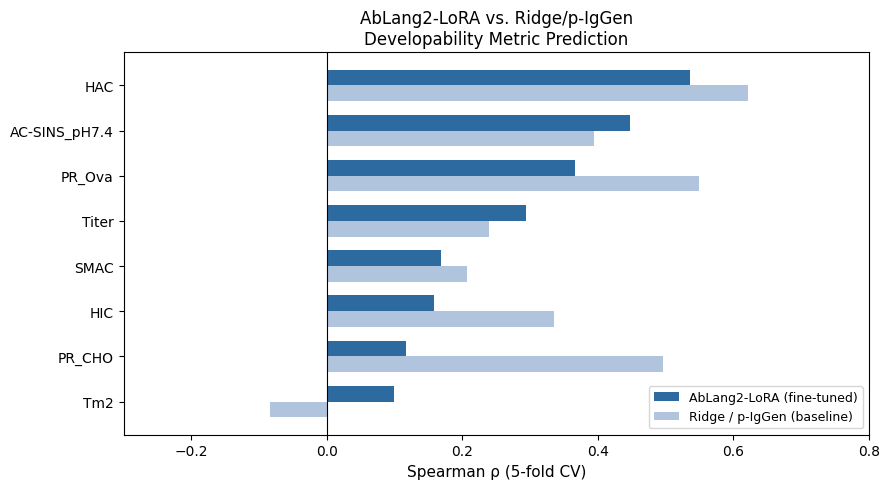

In [16]:
import matplotlib.pyplot as plt

# p-IgGen cross-validation Spearman rho
RIDGE_PIGGEN_RHO = {
    "HAC":            0.621,
    "PR_Ova":         0.549,
    "PR_CHO":         0.496,
    "AC-SINS_pH7.4":  0.394,
    "HIC":            0.335,
    "Titer":          0.239,
    "SMAC":           0.207,
    "Purity":         0.180,
    "Tm2":           -0.084,
    "SEC_%Monomer":  -0.101,
}

comparison = regression_summary[["target", "rho_mean"]].copy()
comparison.rename(columns={"rho_mean": "AbLang2_LoRA"}, inplace=True)
comparison["Ridge_pIgGen"] = comparison["target"].map(RIDGE_PIGGEN_RHO)
comparison = comparison.dropna(subset=["Ridge_pIgGen"]).sort_values("AbLang2_LoRA", ascending = True)

fig, ax = plt.subplots(figsize = (9, 5))
y = np.arange(len(comparison))
w = 0.35
ax.barh(y + w/2, comparison["AbLang2_LoRA"], w, label = "AbLang2-LoRA (fine-tuned)", color="#2d6a9f")
ax.barh(y - w/2, comparison["Ridge_pIgGen"], w, label = "Ridge / p-IgGen (baseline)", color="#b0c4de")
ax.axvline(0, color = "black", linewidth = 0.8)
ax.set_yticks(y)
ax.set_yticklabels(comparison["target"].values, fontsize = 10)
ax.set_xlabel("Spearman rho (5-fold CV)", fontsize = 11)
ax.set_title("AbLang2-LoRA vs. Ridge/p-IgGen\nDevelopability Metric Prediction", fontsize = 12)
ax.legend(fontsize=9)
ax.set_xlim(-0.3, 0.8)
plt.tight_layout()
plt.show()
